# 02 — Single Station PM2.5 Model (Wałbrzych)

Prediction of daily PM2.5 concentrations at a single GIOŚ station
using Open-Meteo meteorological data as predictors.

**Pipeline:**
1. Load PM2.5 (GIOŚ) and weather (Open-Meteo) for Wałbrzych
2. Feature engineering — lag features, calendar variables
3. Train/test split by time (2016–2018 train, 2019 test)
4. Hyperparameter tuning — `RandomizedSearchCV` with `TimeSeriesSplit`
5. Final model evaluation on held-out 2019 test set
6. Feature importance

**Models:** Random Forest · LightGBM

**Target:** PM2.5 daily mean [µg/m³]  
**Station:** DsWalbrzWyso (50.769°N, 16.270°E)

## 0. Imports & configuration

In [35]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform, loguniform

from read_data import read_data
from read_openmeteo import read_openmeteo

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Station configuration ─────────────────────────────────────────────────────
STATION_CODE = "DsWalbrzWyso"
STATION_LAT  = 50.768745
STATION_LON  = 16.269667

# ── Time split ────────────────────────────────────────────────────────────────
TRAIN_YEARS = [2016, 2017, 2018]
TEST_YEAR   = 2019

# ── Lag features (days) ───────────────────────────────────────────────────────
LAG_DAYS = [1, 2, 3]

# ── Cross-validation ──────────────────────────────────────────────────────────
N_CV_SPLITS  = 5     # TimeSeriesSplit folds on training data
N_ITER_SEARCH = 50   # RandomizedSearchCV iterations

RANDOM_STATE = 42

print("Configuration loaded.")
print(f"  Station : {STATION_CODE}")
print(f"  Train   : {TRAIN_YEARS}")
print(f"  Test    : {TEST_YEAR}")
print(f"  CV folds: {N_CV_SPLITS} (TimeSeriesSplit)")

Configuration loaded.
  Station : DsWalbrzWyso
  Train   : [2016, 2017, 2018]
  Test    : 2019
  CV folds: 5 (TimeSeriesSplit)


## 1. Data — PM2.5 and meteorology

In [36]:
# ── PM2.5 (GIOŚ, 24h averages) ───────────────────────────────────────────────
df_merged, _ = read_data("PM25_24g")

pm25 = df_merged[STATION_CODE].copy()
pm25.index = pd.to_datetime(pm25.index)
pm25 = pm25[(pm25.index.year >= min(TRAIN_YEARS)) & (pm25.index.year <= TEST_YEAR)]
pm25.name = "pm25"

print(f"PM2.5 — {len(pm25)} days, {pm25.isna().sum()} missing ({100*pm25.isna().mean():.1f}%)")
print(f"  Range : {pm25.index.min().date()} – {pm25.index.max().date()}")
print(f"  Stats : mean={pm25.mean():.1f}  median={pm25.median():.1f}  max={pm25.max():.1f} µg/m³")

Wczytywanie: .\2016\2016_PM25_24g.xlsx
Wczytywanie: .\2017\2017_PM25_24g.xlsx
Wczytywanie: .\2018\2018_PM25_24g.xlsx
Wczytywanie: .\2019\2019_PM25_24g.xlsx
            DsLegAlRzecz  DsOsieczow21  DsWalbrzWyso  DsWrocNaGrob  \
Data                                                                 
2016-01-01          59.3         19.00           NaN           NaN   
2016-01-02          54.7         48.50           NaN           NaN   
2016-01-03          69.0         54.90           NaN           NaN   
2016-01-04          80.1         78.40           NaN           NaN   
2016-01-05         100.5         79.50           NaN         80.40   
...                  ...           ...           ...           ...   
2019-12-27           NaN          7.43          7.34          7.00   
2019-12-28           NaN          7.75          7.64          5.74   
2019-12-29           NaN         14.62         11.79          9.29   
2019-12-30           NaN         12.79         13.46         19.80   
2019

In [37]:
# ── Open-Meteo weather (daily) ────────────────────────────────────────────────
df_weather, elevation = read_openmeteo(STATION_LON, STATION_LAT)

df_weather.index = pd.to_datetime(df_weather.index)
# Strip timezone if present so the join works cleanly
if df_weather.index.tz is not None:
    df_weather.index = df_weather.index.tz_localize(None)

print(f"Weather — {len(df_weather)} days | elevation: {elevation:.0f} m a.s.l.")
print(f"  Variables: {list(df_weather.columns)}")

Coordinates: 50.79085922241211°N 16.33452033996582°E
Elevation: 441.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                            date  boundary_layer_height
0     2016-01-01 00:00:00+00:00                  125.0
1     2016-01-01 01:00:00+00:00                  135.0
2     2016-01-01 02:00:00+00:00                  145.0
3     2016-01-01 03:00:00+00:00                  145.0
4     2016-01-01 04:00:00+00:00                  140.0
...                         ...                    ...
35083 2020-01-01 19:00:00+00:00                   50.0
35084 2020-01-01 20:00:00+00:00                   50.0
35085 2020-01-01 21:00:00+00:00                   45.0
35086 2020-01-01 22:00:00+00:00                   40.0
35087 2020-01-01 23:00:00+00:00                   35.0

[35088 rows x 2 columns]

Daily data
                           date  temperature_2m_min  wind_speed_10m_max  \
0    2016-01-01 00:00:00+00:00           -3.439500           11.090103   
1    2016-01-02 00:00:00+00:00

In [38]:
# ── Merge ─────────────────────────────────────────────────────────────────────
df = df_weather.join(pm25, how="inner")
df = df[(df.index.year >= min(TRAIN_YEARS)) & (df.index.year <= TEST_YEAR)]
df = df.sort_index()

# TUTAJ DODAJEMY IMPUTACJĘ:
# Wypełniamy braki PM2.5 poprzednią znaną wartością (forward fill)
df['pm25'] = df['pm25'].ffill()

print(f"Merged dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  PM2.5 missing after merge: {df['pm25'].isna().sum()}")
df.head()

Merged dataset: 1461 rows × 10 columns
  PM2.5 missing after merge: 15


,temperature_2m_min,wind_speed_10m_max,wind_direction_10m_dominant,cloud_cover_mean,surface_pressure_mean,dew_point_2m_mean,relative_humidity_2m_min,wind_speed_10m_mean,boundary_layer_height,pm25
2016-01-01,-3.439500,11.090103,271.172089,100.000000,971.187439,-2.377000,70.818085,8.582045,208.750000,NaN
2016-01-02,-10.039499,14.777550,95.268745,91.500000,969.175354,-9.435332,68.535233,10.628380,249.583328,NaN
2016-01-03,-12.489500,12.101570,121.725021,72.750000,962.818542,-14.168667,68.557549,9.607747,237.083328,NaN
2016-01-04,-9.689500,20.929596,177.962936,94.000000,946.411682,-12.758251,56.740337,15.009780,490.833344,NaN
2016-01-05,-7.089500,11.269782,183.254959,92.541664,945.822754,-7.349917,72.902756,6.544238,204.166672,NaN


## 2. Exploratory data analysis

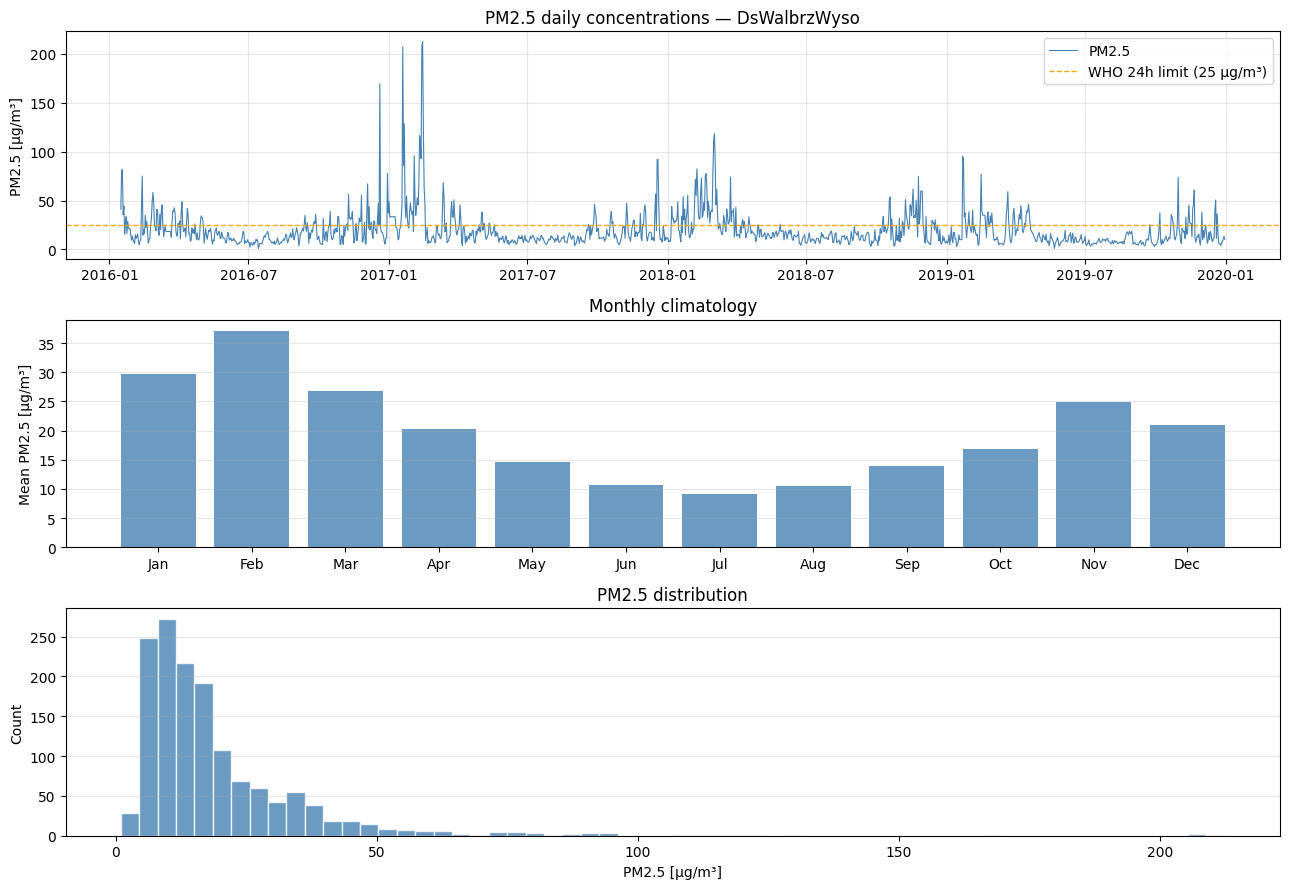

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9))

# Time series
ax = axes[0]
ax.plot(df.index, df["pm25"], linewidth=0.8, color="steelblue", label="PM2.5")
ax.axhline(25, color="orange", linestyle="--", linewidth=1, label="WHO 24h limit (25 µg/m³)")
ax.set_ylabel("PM2.5 [µg/m³]")
ax.set_title(f"PM2.5 daily concentrations — {STATION_CODE}")
ax.legend()
ax.grid(True, alpha=0.3)

# Monthly climatology
ax = axes[1]
monthly = df.groupby(df.index.month)["pm25"].mean()
ax.bar(monthly.index, monthly.values, color="steelblue", alpha=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("Mean PM2.5 [µg/m³]")
ax.set_title("Monthly climatology")
ax.grid(True, alpha=0.3, axis="y")

# Distribution
ax = axes[2]
ax.hist(df["pm25"].dropna(), bins=60, color="steelblue", alpha=0.8, edgecolor="white")
ax.set_xlabel("PM2.5 [µg/m³]")
ax.set_ylabel("Count")
ax.set_title("PM2.5 distribution")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("plot_01_eda_pm25.png", dpi=150, bbox_inches="tight")
plt.show()

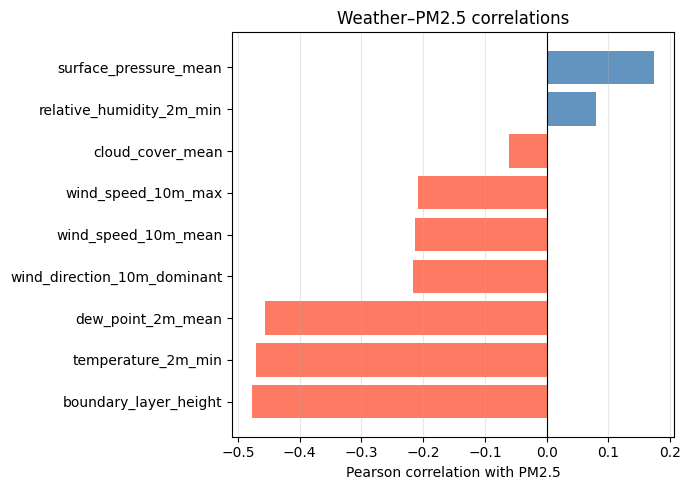

In [40]:
# Correlation of weather variables with PM2.5
weather_cols = [c for c in df.columns if c != "pm25"]
corr = df[weather_cols + ["pm25"]].corr()["pm25"].drop("pm25").sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["tomato" if v < 0 else "steelblue" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with PM2.5")
ax.set_title("Weather–PM2.5 correlations")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("plot_02_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Feature engineering

In [41]:
# Calendar features
df["month"]   = df.index.month
df["weekday"] = df.index.weekday
df["yearday"] = df.index.dayofyear

# Cyclic encoding of month and yearday (avoids ordinal artifacts)
df["month_sin"]   = np.sin(2 * np.pi * df["month"]   / 12)
df["month_cos"]   = np.cos(2 * np.pi * df["month"]   / 12)
df["yearday_sin"] = np.sin(2 * np.pi * df["yearday"] / 365)
df["yearday_cos"] = np.cos(2 * np.pi * df["yearday"] / 365)

# Lag features for weather variables
# NOTE: lag is applied BEFORE the split — safe because we shift by date,
# not by row index, and the split is strictly temporal.
LAG_FEATURES = [
    #"pm25", #added!!!!!!
    "temperature_2m_min",
    "wind_speed_10m_max",
    "wind_speed_10m_mean",
    "wind_direction_10m_dominant",
    "cloud_cover_mean",
    "surface_pressure_mean",
    "dew_point_2m_mean",
    "relative_humidity_2m_min",
    "boundary_layer_height",
]

for col in LAG_FEATURES:
    if col not in df.columns:
        continue
    for lag in LAG_DAYS:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

# Drop rows where lags introduced NaN (first LAG_DAYS days)
df = df.dropna(subset=["pm25"])
df = df.dropna(subset=[f"{col}_lag{max(LAG_DAYS)}"
                        for col in LAG_FEATURES if col in df.columns])

print(f"After feature engineering: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Features: {df.shape[1] - 1} (excl. target)")

After feature engineering: 1446 rows × 44 columns
  Features: 43 (excl. target)


## 4. Train / test split

Strict temporal split: **2016–2018 → training**, **2019 → test**.  
The test set is never touched during hyperparameter search.

In [42]:
# Define feature columns (everything except target and raw calendar cols
# that are superseded by cyclic encoding)
DROP_COLS = ["pm25", "month", "weekday", "yearday"]
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

train = df[df.index.year.isin(TRAIN_YEARS)]
test  = df[df.index.year == TEST_YEAR]

X_train = train[FEATURE_COLS]
y_train = train["pm25"]
X_test  = test[FEATURE_COLS]
y_test  = test["pm25"]

print(f"Train : {len(train)} samples  ({train.index.min().date()} – {train.index.max().date()})")
print(f"Test  : {len(test)}  samples  ({test.index.min().date()}  – {test.index.max().date()})")
print(f"Features: {len(FEATURE_COLS)}")

Train : 1081 samples  (2016-01-16 – 2018-12-31)
Test  : 365  samples  (2019-01-01  – 2019-12-31)
Features: 40


## 5. Cross-validation strategy

`TimeSeriesSplit` with `N_CV_SPLITS` folds applied **only to the training set**.  
Each fold expands the training window chronologically — no data leakage.

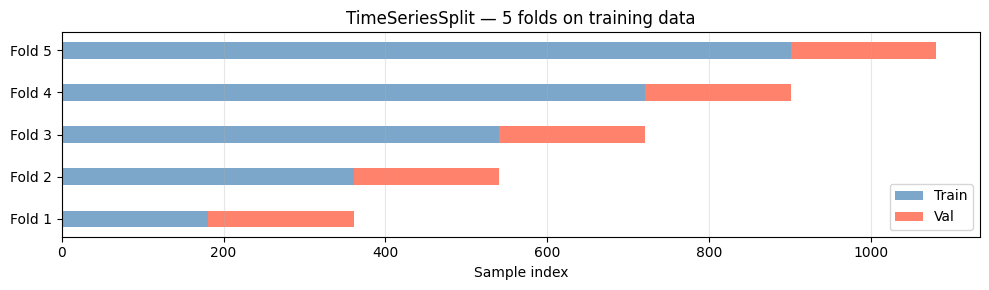

In [43]:
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

# Visualise the CV folds
fig, ax = plt.subplots(figsize=(10, 3))
dates = train.index

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    ax.barh(fold, width=len(tr_idx),  left=0,            height=0.4,
            color="steelblue", alpha=0.7, label="Train" if fold == 0 else "")
    ax.barh(fold, width=len(val_idx), left=len(tr_idx),  height=0.4,
            color="tomato",    alpha=0.8, label="Val"   if fold == 0 else "")

ax.set_yticks(range(N_CV_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_CV_SPLITS)])
ax.set_xlabel("Sample index")
ax.set_title(f"TimeSeriesSplit — {N_CV_SPLITS} folds on training data")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("plot_03_cv_folds.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Model training — Random Forest

In [44]:
rf_param_dist = {
    "model__n_estimators":      randint(100, 500),
    "model__max_depth":         [None, 10, 20, 30, 40],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf":  randint(1, 10),
    "model__max_features":      ["sqrt", "log2", 0.5, 0.7],
}

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),          # RF is scale-invariant but keeps pipeline uniform
    ("model",  RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_search = RandomizedSearchCV(
    estimator          = rf_pipeline,
    param_distributions= rf_param_dist,
    n_iter             = N_ITER_SEARCH,
    cv                 = tscv,                       # TimeSeriesSplit — no leakage
    scoring            = "neg_root_mean_squared_error",
    n_jobs             = -1,
    random_state       = RANDOM_STATE,
    verbose            = 1,
    refit              = True,                       # refit best params on full train set
)

rf_search.fit(X_train, y_train)

print("\nBest RF parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: {-rf_search.best_score_:.3f} µg/m³")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best RF parameters:
  model__max_depth: None
  model__max_features: 0.5
  model__min_samples_leaf: 1
  model__min_samples_split: 3
  model__n_estimators: 229

Best CV RMSE: 13.348 µg/m³


## 7. Model training — LightGBM

In [45]:
lgb_param_dist = {
    "model__n_estimators":      randint(100, 600),
    "model__max_depth":         randint(3, 12),
    "model__learning_rate":     uniform(0.01, 0.2),
    "model__num_leaves":        randint(15, 127),
    "model__min_child_samples": randint(5, 50),
    "model__subsample":         uniform(0.6, 0.4),
    "model__colsample_bytree":  uniform(0.6, 0.4),
    "model__reg_alpha":         uniform(0, 1),
    "model__reg_lambda":        uniform(0, 1),
}

lgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)),
])

lgb_search = RandomizedSearchCV(
    estimator          = lgb_pipeline,
    param_distributions= lgb_param_dist,
    n_iter             = N_ITER_SEARCH,
    cv                 = tscv,
    scoring            = "neg_root_mean_squared_error",
    n_jobs             = -1,
    random_state       = RANDOM_STATE,
    verbose            = 1,
    refit              = True,
)

lgb_search.fit(X_train, y_train)

print("\nBest LightGBM parameters:")
for k, v in lgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: {-lgb_search.best_score_:.3f} µg/m³")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best LightGBM parameters:
  model__colsample_bytree: 0.8010548372420768
  model__learning_rate: 0.12538077692527183
  model__max_depth: 3
  model__min_child_samples: 9
  model__n_estimators: 416
  model__num_leaves: 62
  model__reg_alpha: 0.2807723624408558
  model__reg_lambda: 0.02431596643145384
  model__subsample: 0.858188918362867

Best CV RMSE: 13.247 µg/m³


## 8. Model training — XGBoost

In [46]:
xgb_param_dist = {
    "model__n_estimators":      randint(100, 600),
    "model__max_depth":         randint(3, 10),
    "model__learning_rate":     loguniform(0.01, 0.3),
    "model__subsample":         uniform(0.6, 0.4),
    "model__colsample_bytree":  uniform(0.6, 0.4),
    "model__reg_alpha":         loguniform(1e-3, 10),
    "model__reg_lambda":        loguniform(1e-3, 10),
    "model__min_child_weight":  randint(1, 10),
}

xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  xgb.XGBRegressor(
        random_state=RANDOM_STATE,
        tree_method="hist",    # fast histogram-based algorithm
        verbosity=0,
    )),
])

xgb_search = RandomizedSearchCV(
    estimator          = xgb_pipeline,
    param_distributions= xgb_param_dist,
    n_iter             = N_ITER_SEARCH,
    cv                 = tscv,
    scoring            = "neg_root_mean_squared_error",
    n_jobs             = -1,
    random_state       = RANDOM_STATE,
    verbose            = 1,
    refit              = True,
)

xgb_search.fit(X_train, y_train)

print("\nBest XGBoost parameters:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: {-xgb_search.best_score_:.3f} µg/m³")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best XGBoost parameters:
  model__colsample_bytree: 0.9212559025519583
  model__learning_rate: 0.04950978760714172
  model__max_depth: 4
  model__min_child_weight: 6
  model__n_estimators: 569
  model__reg_alpha: 0.1390268671103501
  model__reg_lambda: 0.002296989871634209
  model__subsample: 0.9341209982356952

Best CV RMSE: 12.832 µg/m³


## 9. Evaluation on test set (2019)

In [47]:
def evaluate(name: str, model, X_test, y_test) -> dict:
    """Compute test-set metrics and return as dict."""
    y_pred = model.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    bias   = float(np.mean(y_pred - y_test))
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2,
            "Bias": bias, "y_pred": y_pred}


results = [
    evaluate("Random Forest", rf_search.best_estimator_,  X_test, y_test),
    evaluate("LightGBM",      lgb_search.best_estimator_, X_test, y_test),
    evaluate("XGBoost",       xgb_search.best_estimator_, X_test, y_test),
]

df_metrics = pd.DataFrame(results).set_index("model").drop(columns="y_pred")
print("=" * 50)
print("TEST SET METRICS (2019)")
print("=" * 50)
print(df_metrics.round(3).to_string())

TEST SET METRICS (2019)
                 RMSE    MAE     R2   Bias
model                                     
Random Forest  10.154  6.901  0.371  2.973
LightGBM       10.347  6.576  0.347  2.788
XGBoost        10.251  6.321  0.359  2.726


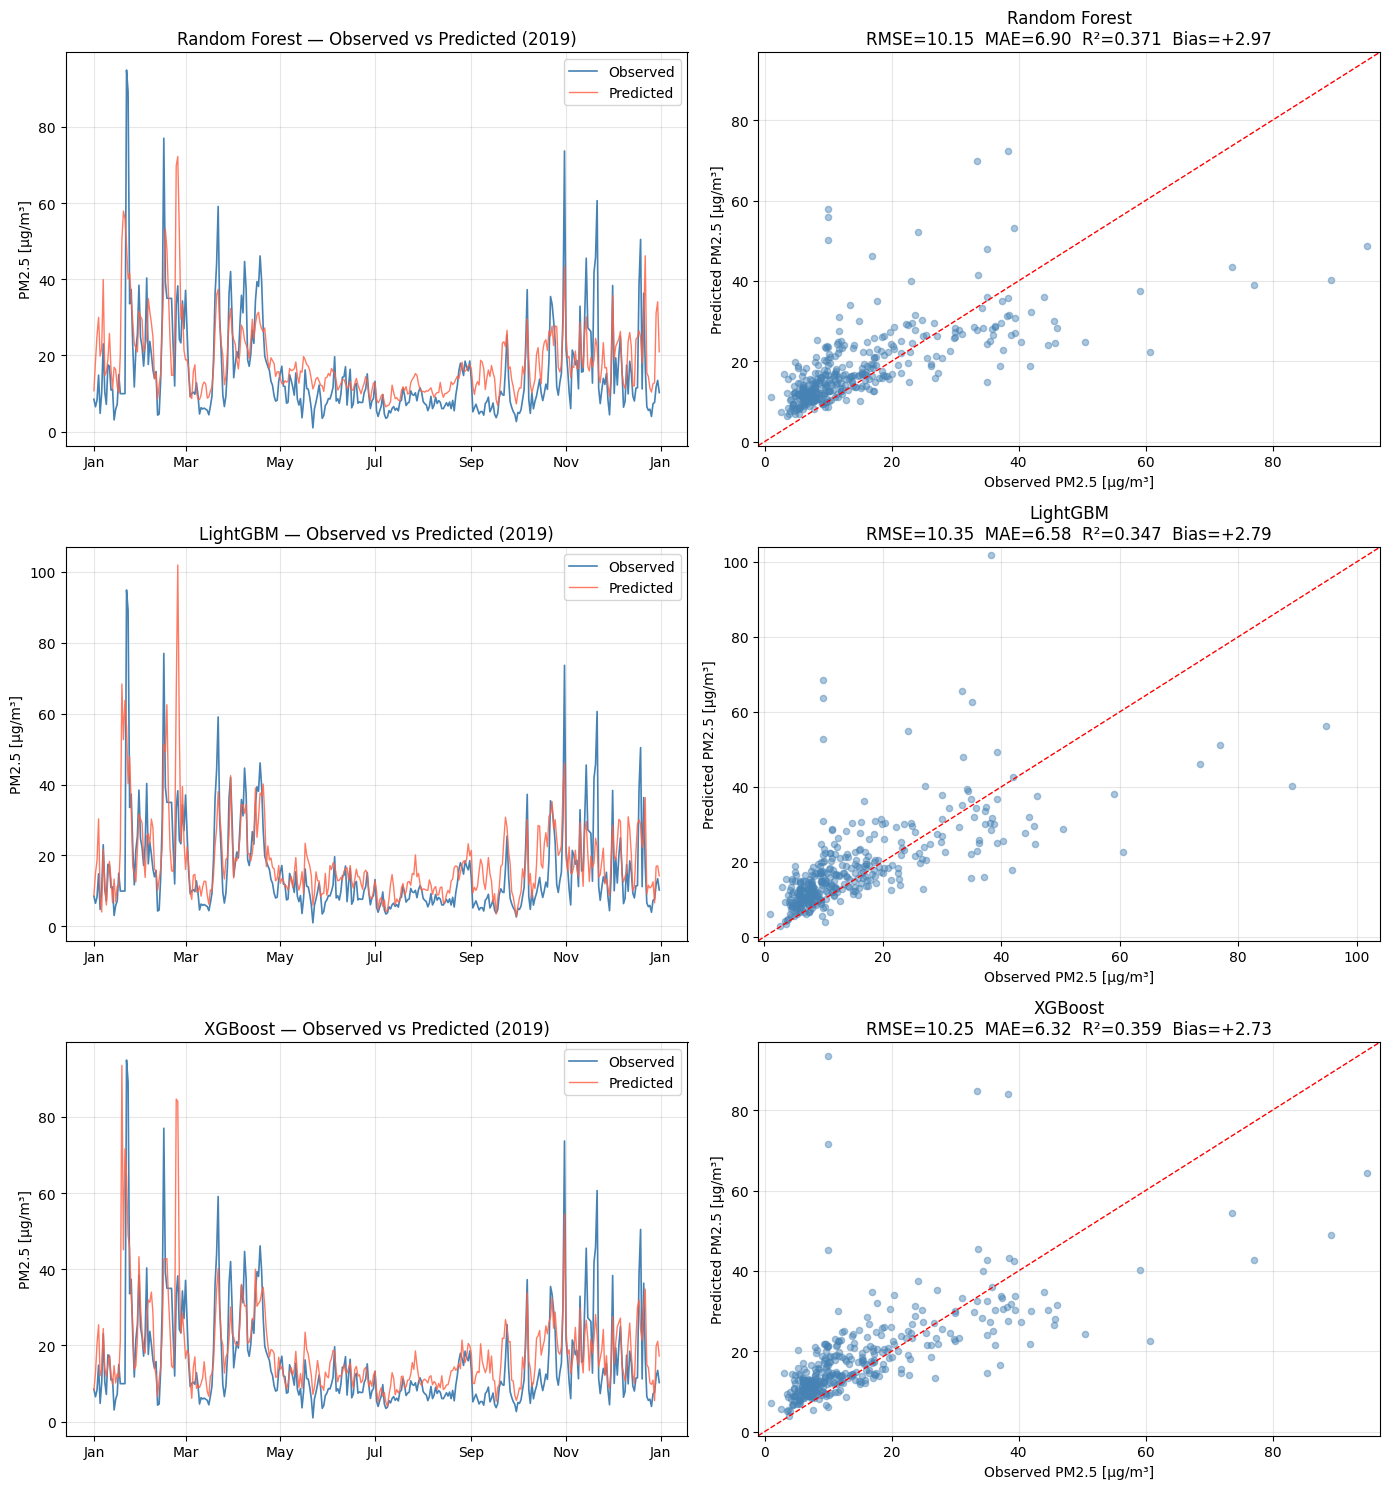

In [48]:
fig, axes = plt.subplots(len(results), 2, figsize=(14, 5 * len(results)))

for row, res in enumerate(results):
    y_pred = res["y_pred"]
    name   = res["model"]

    # Time series: observed vs predicted
    ax = axes[row, 0]
    ax.plot(test.index, y_test.values,  label="Observed",  linewidth=1.2, color="steelblue")
    ax.plot(test.index, y_pred,         label="Predicted", linewidth=1.0,
            color="tomato", alpha=0.85)
    ax.set_title(f"{name} — Observed vs Predicted (2019)")
    ax.set_ylabel("PM2.5 [µg/m³]")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    # Scatter: observed vs predicted
    ax = axes[row, 1]
    lim = [min(y_test.min(), y_pred.min()) - 2,
           max(y_test.max(), y_pred.max()) + 2]
    ax.scatter(y_test, y_pred, alpha=0.45, s=20, color="steelblue")
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Observed PM2.5 [µg/m³]")
    ax.set_ylabel("Predicted PM2.5 [µg/m³]")
    ax.set_title(
        f"{name}\n"
        f"RMSE={res['RMSE']:.2f}  MAE={res['MAE']:.2f}  "
        f"R²={res['R2']:.3f}  Bias={res['Bias']:+.2f}"
    )
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_04_test_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. CV learning curves

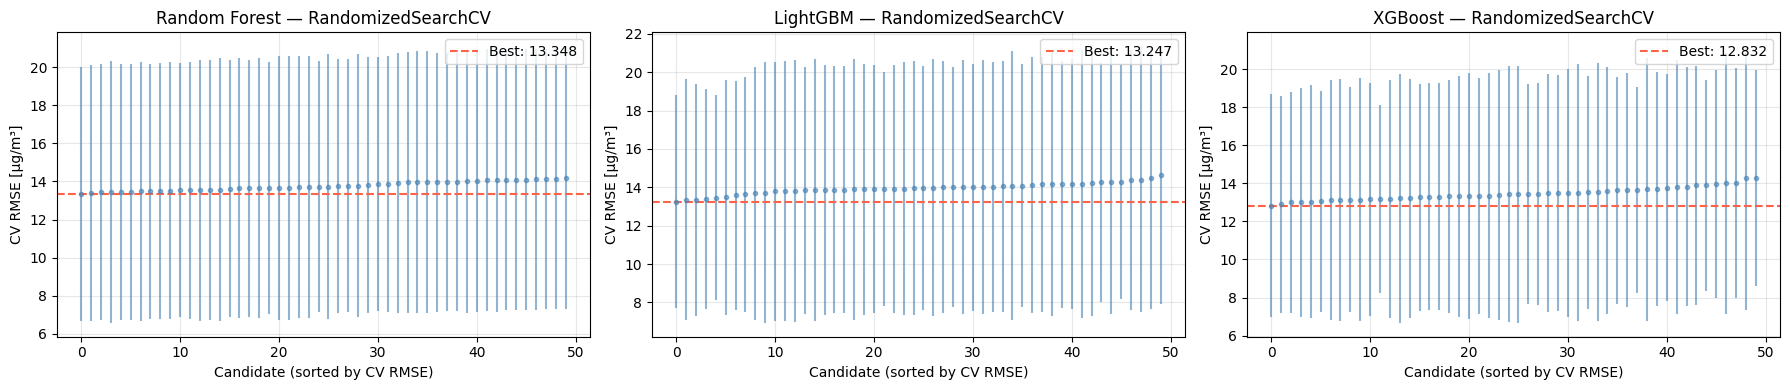

In [49]:
def plot_cv_results(search, title: str, ax):
    """Plot distribution of CV scores across all RandomizedSearchCV iterations."""
    cv_results = pd.DataFrame(search.cv_results_)
    scores = -cv_results["mean_test_score"]   # convert neg_RMSE → RMSE
    stds   =  cv_results["std_test_score"]

    sorted_idx = scores.argsort()
    ax.errorbar(
        x=range(len(scores)),
        y=scores.iloc[sorted_idx],
        yerr=stds.iloc[sorted_idx],
        fmt="o", markersize=3, alpha=0.6, color="steelblue",
    )
    ax.axhline(-search.best_score_, color="tomato", linestyle="--",
               label=f"Best: {-search.best_score_:.3f}")
    ax.set_xlabel("Candidate (sorted by CV RMSE)")
    ax.set_ylabel("CV RMSE [µg/m³]")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_cv_results(rf_search,  "Random Forest — RandomizedSearchCV",  axes[0])
plot_cv_results(lgb_search, "LightGBM — RandomizedSearchCV",       axes[1])
plot_cv_results(xgb_search, "XGBoost — RandomizedSearchCV",        axes[2])
plt.tight_layout()
plt.savefig("plot_05_cv_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Feature importance

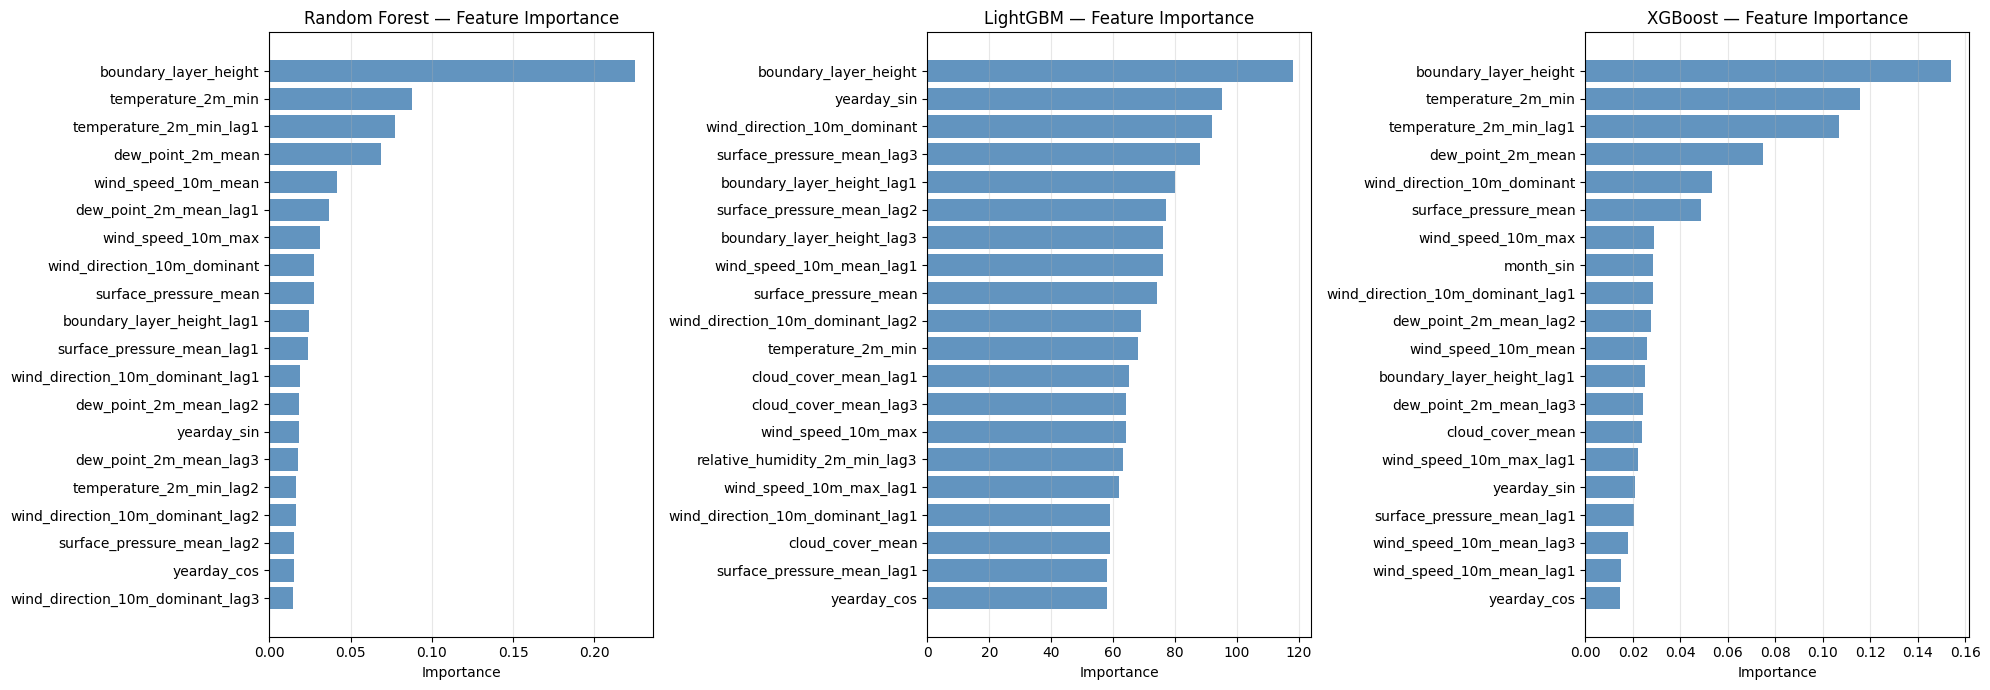

In [50]:
def plot_feature_importance(model_step, feature_names, title: str, ax, top_n: int = 20):
    """Bar chart of top-N feature importances."""
    importances = model_step.feature_importances_
    idx = np.argsort(importances)[-top_n:]

    ax.barh(
        np.array(feature_names)[idx],
        importances[idx],
        color="steelblue", alpha=0.85,
    )
    ax.set_xlabel("Importance")
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="x")


rf_model  = rf_search.best_estimator_.named_steps["model"]
lgb_model = lgb_search.best_estimator_.named_steps["model"]
xgb_model = xgb_search.best_estimator_.named_steps["model"]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
plot_feature_importance(rf_model,  FEATURE_COLS, "Random Forest — Feature Importance",  axes[0])
plot_feature_importance(lgb_model, FEATURE_COLS, "LightGBM — Feature Importance",       axes[1])
plot_feature_importance(xgb_model, FEATURE_COLS, "XGBoost — Feature Importance",        axes[2])
plt.tight_layout()
plt.savefig("plot_06_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Summary

In [51]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Station        : {STATION_CODE}")
print(f"Train period   : {min(TRAIN_YEARS)}–{max(TRAIN_YEARS)} ({len(train)} days)")
print(f"Test period    : {TEST_YEAR} ({len(test)} days)")
print(f"Features used  : {len(FEATURE_COLS)}")
print(f"CV strategy    : TimeSeriesSplit, {N_CV_SPLITS} folds")
print(f"Search iters   : {N_ITER_SEARCH} per model")
print()
print("Test-set metrics:")
print(df_metrics.round(3).to_string())
print()
best_model = df_metrics["RMSE"].idxmin()
print(f"Best model (RMSE): {best_model}")
print()
print("Saved plots:")
for p in ["plot_01_eda_pm25.png", "plot_02_correlations.png",
          "plot_03_cv_folds.png",  "plot_04_test_evaluation.png",
          "plot_05_cv_results.png", "plot_06_feature_importance.png"]:
    print(f"  {p}")

SUMMARY
Station        : DsWalbrzWyso
Train period   : 2016–2018 (1081 days)
Test period    : 2019 (365 days)
Features used  : 40
CV strategy    : TimeSeriesSplit, 5 folds
Search iters   : 50 per model

Test-set metrics:
                 RMSE    MAE     R2   Bias
model                                     
Random Forest  10.154  6.901  0.371  2.973
LightGBM       10.347  6.576  0.347  2.788
XGBoost        10.251  6.321  0.359  2.726

Best model (RMSE): Random Forest

Saved plots:
  plot_01_eda_pm25.png
  plot_02_correlations.png
  plot_03_cv_folds.png
  plot_04_test_evaluation.png
  plot_05_cv_results.png
  plot_06_feature_importance.png
